# Momentum + volatility targeting en ETFs sectoriales europeos (versión simplificada)

Este notebook es una versión reducida y simplificada del análisis completo del TFM. La idea es que se pueda leer de arriba a abajo y quede claro qué se hace en cada paso, sin repartir el código en muchos módulos ni añadir comprobaciones de más.

Lo que hacemos, en orden:
1. Descargar los precios de 19 ETFs sectoriales europeos.
2. Construir la señal momentum (12-1 meses) y comprobar si predice algo.
3. Montar una cartera *long-short* con esa señal y simular su historia.
4. Ajustar el tamaño de la cartera según su propia volatilidad reciente (*volatility targeting*).
5. Descontar costes de negociación reales y ver si la mejora sobrevive.
6. Comprobar que el resultado se sostiene en distintos sub-periodos y con distintos niveles de coste.
7. Contrastar todo contra un índice académico (Kenneth French) para saber si el problema es el mecanismo o el universo tan pequeño de ETFs.

No está el conjunto completo de comprobaciones de robustez del TFM (por ejemplo, no repetimos el análisis con distintas ventanas de formación de la señal o distintas frecuencias de rebalanceo) — esto es el MVP, la versión mínima que ya da los resultados centrales.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.precision", 3)

## 1. Descargar los precios de los 19 ETFs

El universo son los ETFs sectoriales de la familia iShares STOXX Europe 600, que cotizan en la bolsa alemana (Xetra). Sus tickers están guardados en `universo_etfs.csv`.

Si ya tenemos los precios descargados de antes (`data/raw/precios_long.parquet`, del análisis completo) los reutilizamos directamente, para que este notebook dé siempre los mismos números. Si no, los descargamos con `yfinance` y los guardamos en un parquet local.

In [2]:
RUTA_PRECIOS_TFM = "data/raw/precios_long.parquet"  # ya descargados para el análisis completo
RUTA_PRECIOS_PROPIA = "precios_etfs.parquet"

universo = pd.read_csv("universo_etfs.csv")

if os.path.exists(RUTA_PRECIOS_TFM):
    precios_long = pd.read_parquet(RUTA_PRECIOS_TFM)
elif os.path.exists(RUTA_PRECIOS_PROPIA):
    precios_long = pd.read_parquet(RUTA_PRECIOS_PROPIA)
else:
    trozos = []
    for fila in universo.itertuples():
        historia = yf.Ticker(fila.yahoo_ticker).history(period="max", auto_adjust=True)
        historia = historia[["Close"]].reset_index()
        historia.columns = ["fecha", "adj_close"]
        historia["fecha"] = pd.to_datetime(historia["fecha"]).dt.tz_localize(None)
        historia["ticker"] = fila.ticker
        trozos.append(historia)
    precios_long = pd.concat(trozos, ignore_index=True)
    precios_long.to_parquet(RUTA_PRECIOS_PROPIA)

print(precios_long["ticker"].nunique(), "ETFs,", len(precios_long), "filas")
precios_long.head()

19 ETFs, 90097 filas


,fecha,ticker,sector,adj_close,volume
0,2008-01-02,EXH1,Oil & Gas,24.993,0
1,2008-01-03,EXH1,Oil & Gas,25.465,0
2,2008-01-04,EXH1,Oil & Gas,25.088,0
3,2008-01-07,EXH1,Oil & Gas,25.443,0
4,2008-01-08,EXH1,Oil & Gas,25.319,0


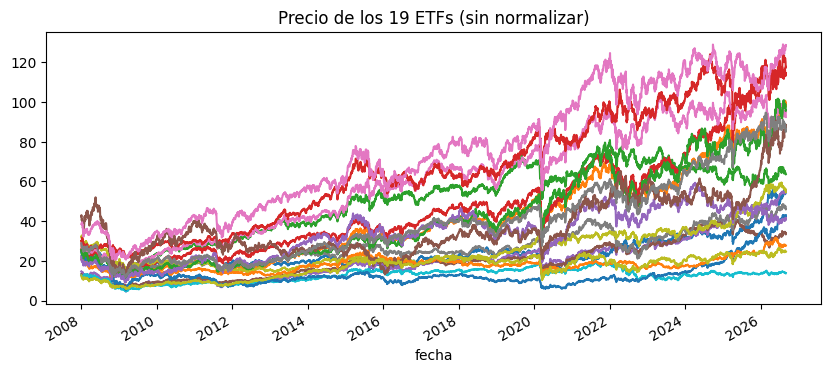

In [3]:
# formato ancho: una fila por fecha, una columna por ETF
precios_diarios = precios_long.pivot(index="fecha", columns="ticker", values="adj_close").sort_index()
precios_diarios.plot(figsize=(10, 4), legend=False, title="Precio de los 19 ETFs (sin normalizar)")
plt.show()

## 2. La señal momentum (12-1)

La señal de cada ETF en el mes *t* es su retorno acumulado entre hace 12 meses y hace 2 meses (se deja fuera el último mes, por un efecto de reversión a muy corto plazo ya documentado en la literatura):

$$ señal_t = \frac{P_{t-2}}{P_{t-12}} - 1 $$

Solo damos por válida la señal de un ETF en el mes *t* si tiene los 12 meses anteriores completos, sin huecos. Si le falta algún mes, la señal queda en blanco (NaN) — no la rellenamos ni la estimamos.

In [4]:
# precios mensuales: el último precio disponible de cada mes
precios_mensual = precios_diarios.resample("ME").last()

lookback, skip = 12, 2
senal = precios_mensual.shift(skip) / precios_mensual.shift(lookback) - 1.0

# solo vale si hay 12 meses seguidos de datos justo antes
tiene_historia_completa = precios_mensual.shift(1).notna().rolling(lookback).sum() == lookback
senal = senal.where(tiene_historia_completa)

senal.tail()

ticker,EXH1,EXH2,EXH3,EXH4,EXH5,EXH6,EXH7,EXH8,EXH9,EXI5,EXV1,EXV2,EXV3,EXV4,EXV5,EXV6,EXV7,EXV8,EXV9
fecha,,,,,,,,,,,,,,,,,,,
2026-05-31,0.638,-0.028,-0.111,0.037,0.012,-0.313,-0.085,-0.037,0.265,-0.086,0.223,0.146,-0.050,0.056,-0.166,0.545,-0.072,0.009,-0.038
2026-06-30,0.581,0.068,-0.014,0.113,0.084,-0.211,-0.024,0.029,0.299,-0.036,0.355,0.222,0.066,0.084,-0.111,0.687,0.005,0.069,-0.036
2026-07-31,0.405,0.077,0.058,0.128,0.049,-0.108,0.013,0.137,0.245,0.006,0.326,0.293,0.231,0.117,-0.045,0.784,0.074,0.067,-0.003
2026-08-31,0.325,0.069,0.069,0.153,0.113,-0.075,0.017,0.179,0.330,0.040,0.390,0.135,0.341,0.124,-0.168,0.537,0.069,0.101,0.085
2026-09-30,0.459,0.155,0.145,0.129,0.169,-0.063,0.033,0.127,0.280,0.078,0.415,0.140,0.166,0.127,-0.108,0.443,0.137,0.085,0.057


## 3. ¿Predice algo la señal?

Antes de construir ninguna cartera, comprobamos si tiene sentido: cada mes dividimos los ETFs en tres grupos (terciles) según su señal — con solo 19 activos, dividir en 10 grupos (deciles) dejaría grupos de dos ETFs, demasiado pocos para que la media diga algo fiable — y miramos si el grupo con mejor señal gana de verdad más que el grupo con peor señal **el mes siguiente**.

In [5]:
# terciles: tercio superior = ganador, tercio inferior = perdedor
percentil = senal.rank(axis=1, pct=True)
ganador = percentil > 2 / 3
perdedor = percentil <= 1 / 3

# retorno REAL del mes siguiente (esto es lo que se quiere predecir)
retorno_siguiente_mes = precios_mensual.shift(-1) / precios_mensual - 1.0

retorno_ganador = retorno_siguiente_mes[ganador].mean(axis=1)
retorno_perdedor = retorno_siguiente_mes[perdedor].mean(axis=1)
diferencia = (retorno_ganador - retorno_perdedor).dropna()

t_stat = diferencia.mean() / (diferencia.std() / np.sqrt(len(diferencia)))
print(f"diferencia media ganador-perdedor: {diferencia.mean():.4%} mensual")
print(f"t-stat: {t_stat:.2f}  (n = {len(diferencia)} meses)")

diferencia media ganador-perdedor: 0.1802% mensual
t-stat: 0.85  (n = 212 meses)


El t-stat queda por debajo de 1,96 (el umbral habitual para hablar de "significativo"), así que la señal apunta en la dirección correcta pero sin demasiada contundencia estadística. Aun así, seguimos adelante: es una limitación que hay que tener presente, no un motivo para parar.

## 4. Construir la cartera y simular su historia

Con los mismos grupos de antes, montamos una cartera **long-short**: comprada a partes iguales en el tercil ganador (pesos que suman +1) y vendida a partes iguales en el tercil perdedor (pesos que suman -1). Es una cartera autofinanciada: lo que se obtiene de la venta corta cubre la compra larga.

El retorno de la estrategia en el mes siguiente es simplemente la suma de (peso de cada ETF) × (retorno real de ese ETF el mes siguiente).

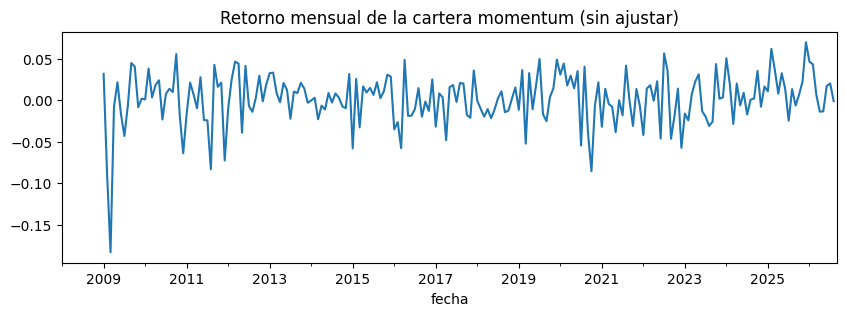

In [6]:
n_ganadores = ganador.sum(axis=1)
n_perdedores = perdedor.sum(axis=1)

peso_largo = ganador.div(n_ganadores.replace(0, np.nan), axis=0).fillna(0.0)
peso_corto = perdedor.div(n_perdedores.replace(0, np.nan), axis=0).fillna(0.0)
pesos = peso_largo - peso_corto

cartera_formada = (n_ganadores > 0) & (n_perdedores > 0)
pesos = pesos.where(cartera_formada)

# comprobación rápida: los pesos largos deben sumar +1 y los cortos -1
assert np.allclose(pesos.where(pesos > 0, 0).sum(axis=1)[cartera_formada], 1.0)
assert np.allclose(pesos.where(pesos < 0, 0).sum(axis=1)[cartera_formada], -1.0)

retorno_cartera = (pesos * retorno_siguiente_mes).sum(axis=1, min_count=1)
retorno_cartera = retorno_cartera.where(cartera_formada)

retorno_cartera.plot(figsize=(10, 3), title="Retorno mensual de la cartera momentum (sin ajustar)")
plt.show()

Para no repetir el mismo cálculo de métricas una y otra vez, escribimos una función `metricas()` que resume cualquier serie de retornos mensuales: retorno y volatilidad anualizados, Sharpe, Sortino, máxima caída (*drawdown*) y su fecha, Calmar, asimetría y curtosis.

In [7]:
def metricas(retornos):
    r = retornos.dropna()
    retorno_anual = r.mean() * 12
    vol_anual = r.std() * np.sqrt(12)

    negativos = r[r < 0]
    sortino = retorno_anual / (negativos.std() * np.sqrt(12))

    valor_liquidativo = (1 + retornos.fillna(0)).cumprod()
    caida = valor_liquidativo / valor_liquidativo.cummax() - 1
    max_caida = caida.min()

    return pd.Series({
        "retorno_anualizado": retorno_anual,
        "vol_anualizada": vol_anual,
        "sharpe": retorno_anual / vol_anual,
        "sortino": sortino,
        "max_drawdown": max_caida,
        "fecha_max_drawdown": caida.idxmin(),
        "calmar": retorno_anual / abs(max_caida),
        "skew": r.skew(),
        "kurtosis_pearson": r.kurt() + 3,
    })


metricas(retorno_cartera)

retorno_anualizado                  0.022
vol_anualizada                      0.107
sharpe                              0.201
sortino                              0.24
max_drawdown                       -0.294
fecha_max_drawdown    2009-08-31 00:00:00
calmar                              0.074
skew                               -1.338
kurtosis_pearson                    8.605
dtype: object

Estos son los números "en bruto", sin ningún ajuste de riesgo ni descuento de costes: Sharpe de 0,20, con una caída máxima de casi el 30&nbsp;% en 2009. Justo el problema que el *volatility targeting* intenta arreglar.

## 5. Ajustar el tamaño de la cartera según su volatilidad reciente

La idea de Barroso y Santa-Clara (2015) es apostar siempre el mismo **nivel de riesgo**, no el mismo capital: si la cartera ha estado agitada últimamente, se reduce el tamaño de la apuesta; si ha estado tranquila, se amplía.

$$ r^{escalado}_t = \frac{\sigma_{objetivo}}{\hat\sigma_{t-1}} \cdot r_t $$

- $\hat\sigma_{t-1}$: la volatilidad reciente de la propia cartera, calculada con los retornos **diarios** de los últimos 126 días de negociación (unos 6 meses) — la convención del artículo original.
- $\sigma_{objetivo}$: el nivel de volatilidad que queremos mantener constante (aquí, la volatilidad anualizada de la propia serie sin ajustar).

*Nota: en el TFM completo se probó primero con una estimación mensual, usando solo 6 observaciones — y salió peor que no ajustar nada, porque 6 datos son muy pocos para calcular una desviación estándar fiable. Aquí vamos directos a la versión que sí funciona.*

Para calcular la volatilidad reciente hace falta el retorno **diario** de la cartera, no solo el mensual. Lo reconstruimos aplicando a cada día el peso que se fijó a fin del mes anterior (sin retocarlo a mitad de mes).

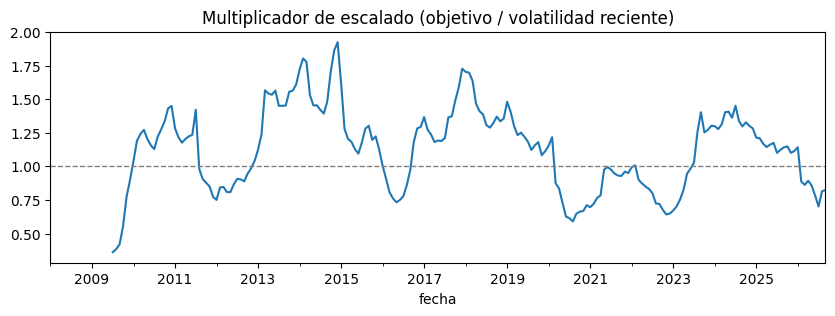

retorno_anualizado                  0.044
vol_anualizada                      0.103
sharpe                              0.432
sortino                             0.662
max_drawdown                       -0.235
fecha_max_drawdown    2023-09-30 00:00:00
calmar                              0.189
skew                               -0.288
kurtosis_pearson                    3.588
dtype: object

In [8]:
# a cada día le asignamos el peso fijado a fin del mes anterior
mes_de_formacion = (pd.PeriodIndex(precios_diarios.index, freq="M") - 1).to_timestamp(how="end").normalize()
pesos_por_dia = pesos.reindex(mes_de_formacion)
pesos_por_dia.index = precios_diarios.index

retorno_diario_etfs = precios_diarios.pct_change()
columnas = retorno_diario_etfs.columns.intersection(pesos.columns)

retorno_cartera_diario = (pesos_por_dia[columnas] * retorno_diario_etfs[columnas]).sum(axis=1, min_count=1)
retorno_cartera_diario = retorno_cartera_diario.where(pesos_por_dia[columnas].notna().any(axis=1))

# volatilidad realizada (126 días), desplazada un día para no usar información del futuro
sigma_diaria = retorno_cartera_diario.rolling(126).std().mul(np.sqrt(252)).shift(1)
sigma_mensual = sigma_diaria.reindex(retorno_cartera.index, method="ffill")

sigma_objetivo = metricas(retorno_cartera)["vol_anualizada"]
multiplicador = sigma_objetivo / sigma_mensual

retorno_cartera_escalada = multiplicador * retorno_cartera

multiplicador.plot(figsize=(10, 3), title="Multiplicador de escalado (objetivo / volatilidad reciente)")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
plt.show()

metricas(retorno_cartera_escalada)

El Sharpe casi se duplica (de 0,20 a 0,43) y la caída máxima baja de -29&nbsp;% a -24&nbsp;%. De momento, todo en bruto — sin pagar nada por operar.

## 6. Costes de negociar de verdad

Nada de esto es gratis. Modelizamos tres cosas:

- **Coste de operar** (*spread* + comisión): 15 puntos básicos (0,15&nbsp;%) por cada unidad de *turnover* — la parte de la cartera que hay que renovar cada mes.
- **Coste de financiación**: el ajuste por volatilidad exige, en los meses tranquilos, exponerse por encima del 100&nbsp;% del capital. Esa parte de más hay que financiarla, a un tipo de interés de referencia (usamos el tipo del BCE, como aproximación al EURIBOR a 1 mes, que no conseguimos en una serie fiable) más un margen de 0,50&nbsp;%.

In [9]:
COSTE_POR_UNIDAD_TURNOVER = (10 + 5) / 10_000  # spread + comisión, en fracción decimal


def turnover_mensual(pesos_cartera):
    llenos = pesos_cartera.fillna(0.0)
    return (llenos - llenos.shift(1).fillna(0.0)).abs().sum(axis=1)


# --- cartera pura ---
turnover_pura = turnover_mensual(pesos)
retorno_cartera_neto = retorno_cartera - turnover_pura * COSTE_POR_UNIDAD_TURNOVER

# --- cartera escalada: turnover + financiación del exceso de exposición ---
pesos_escalados = pesos.mul(multiplicador, axis=0)
turnover_escalada = turnover_mensual(pesos_escalados)
coste_operar_escalada = turnover_escalada * COSTE_POR_UNIDAD_TURNOVER

tipo_bce = pd.read_csv("data/external/ecb_main_refinancing_rate.csv", parse_dates=["observation_date"])
tipo_bce = tipo_bce.set_index("observation_date")["ECBMRRFR"] / 100.0
tipo_bce_mensual = tipo_bce.reindex(retorno_cartera.index, method="ffill")

exceso_de_exposicion = (multiplicador - 1).clip(lower=0.0)
coste_financiacion = exceso_de_exposicion * (tipo_bce_mensual + 0.0050) / 12

retorno_cartera_escalada_neto = retorno_cartera_escalada - coste_operar_escalada - coste_financiacion

tabla = pd.DataFrame({
    "pura bruta": metricas(retorno_cartera),
    "pura neta": metricas(retorno_cartera_neto),
    "escalada bruta": metricas(retorno_cartera_escalada),
    "escalada neta": metricas(retorno_cartera_escalada_neto),
})
tabla.loc["turnover_medio"] = [turnover_pura.mean(), turnover_pura.mean(), turnover_escalada.mean(), turnover_escalada.mean()]
tabla

,pura bruta,pura neta,escalada bruta,escalada neta
retorno_anualizado,0.022,0.007,0.044,0.023
vol_anualizada,0.107,0.107,0.103,0.103
sharpe,0.201,0.065,0.432,0.225
sortino,0.24,0.078,0.662,0.339
max_drawdown,-0.294,-0.364,-0.235,-0.307
fecha_max_drawdown,2009-08-31 00:00:00,2023-09-30 00:00:00,2023-09-30 00:00:00,2023-09-30 00:00:00
calmar,0.074,0.019,0.189,0.076
skew,-1.338,-1.332,-0.288,-0.299
kurtosis_pearson,8.605,8.637,3.588,3.604
turnover_medio,0.772,0.772,0.942,0.942


Neto de costes la ventaja se mantiene (Sharpe 0,065 → 0,225) pero se reduce mucho: comparada contra la pura **bruta** (que todavía no ha pagado nada), la escalada neta apenas gana. ¿De dónde viene el coste? Miramos solo los meses en los que la cartera escalada ya existe (los primeros meses no hay historial suficiente para calcular su volatilidad):

In [10]:
activo = retorno_cartera_escalada.notna()
coste_turnover_pp = coste_operar_escalada[activo].mean() * 12
coste_financiacion_pp = coste_financiacion[activo].mean() * 12

print(f"coste anual por turnover:      {coste_turnover_pp:.2%}")
print(f"coste anual por financiación:  {coste_financiacion_pp:.2%}")

coste anual por turnover:      1.84%
coste anual por financiación:  0.28%


Sorpresa: el turnover pesa muchísimo más que la financiación del apalancamiento (que era, a priori, lo que más se esperaba que pesara). Reajustar la cartera cada mes genera casi tanta rotación como la propia rotación de qué ETFs entran y salen de cada tercil.

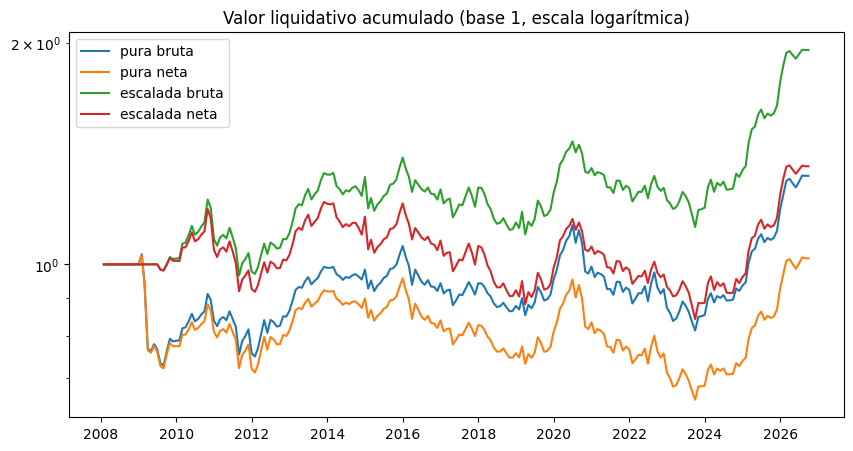

In [11]:
valor_pura_bruta = (1 + retorno_cartera.fillna(0)).cumprod()
valor_pura_neta = (1 + retorno_cartera_neto.fillna(0)).cumprod()
valor_escalada_bruta = (1 + retorno_cartera_escalada.fillna(0)).cumprod()
valor_escalada_neta = (1 + retorno_cartera_escalada_neto.fillna(0)).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(valor_pura_bruta, label="pura bruta")
plt.plot(valor_pura_neta, label="pura neta")
plt.plot(valor_escalada_bruta, label="escalada bruta")
plt.plot(valor_escalada_neta, label="escalada neta")
plt.yscale("log")
plt.legend()
plt.title("Valor liquidativo acumulado (base 1, escala logarítmica)")
plt.show()

## 7. ¿Se sostiene en el tiempo?

Partimos la muestra en tres tramos de tamaño parecido y miramos el Sharpe neto de cada versión en cada uno.

In [12]:
tramos = {
    "2009-2014": ("2009-01-01", "2014-12-31"),
    "2015-2020": ("2015-01-01", "2020-12-31"),
    "2021-2026": ("2021-01-01", "2026-12-31"),
}

filas = {}
for nombre, (inicio, fin) in tramos.items():
    sharpe_pura = metricas(retorno_cartera_neto.loc[inicio:fin])["sharpe"]
    sharpe_escalada = metricas(retorno_cartera_escalada_neto.loc[inicio:fin])["sharpe"]
    filas[nombre] = {"pura": sharpe_pura, "escalada": sharpe_escalada, "ventaja": sharpe_escalada - sharpe_pura}

pd.DataFrame(filas).T

,pura,escalada,ventaja
2009-2014,-0.076,0.316,0.392
2015-2020,-0.077,-0.088,-0.011
2021-2026,0.419,0.504,0.085


Aquí está el problema: la ventaja de la escalada **no es constante**. Está muy concentrada en 2009-2014 y es prácticamente nula en 2015-2020. ¿Es un fallo del mecanismo, o del universo tan pequeño de ETFs? Lo resolvemos en el paso 8, comparando contra un índice académico mucho más amplio.

Antes, una comprobación rápida: ¿y si los costes fueran distintos a los que hemos supuesto?

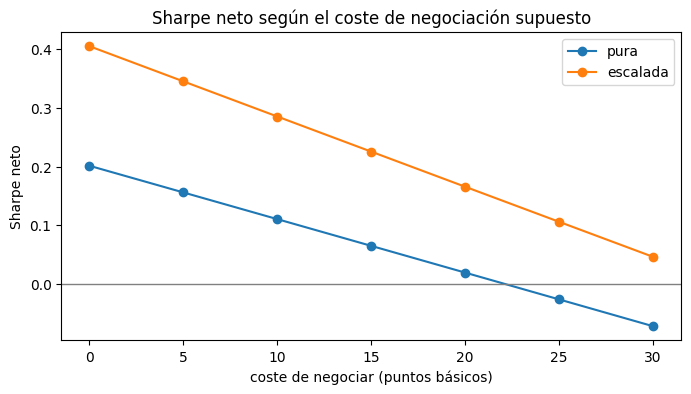

In [13]:
niveles_bps = [0, 5, 10, 15, 20, 25, 30]
sharpe_pura_por_coste = []
sharpe_escalada_por_coste = []

for bps in niveles_bps:
    coste_unidad = bps / 10_000
    r_pura = retorno_cartera - turnover_pura * coste_unidad
    r_escalada = retorno_cartera_escalada - turnover_escalada * coste_unidad - coste_financiacion
    sharpe_pura_por_coste.append(metricas(r_pura)["sharpe"])
    sharpe_escalada_por_coste.append(metricas(r_escalada)["sharpe"])

plt.figure(figsize=(8, 4))
plt.plot(niveles_bps, sharpe_pura_por_coste, marker="o", label="pura")
plt.plot(niveles_bps, sharpe_escalada_por_coste, marker="o", label="escalada")
plt.axhline(0, color="gray", linewidth=1)
plt.xlabel("coste de negociar (puntos básicos)")
plt.ylabel("Sharpe neto")
plt.legend()
plt.title("Sharpe neto según el coste de negociación supuesto")
plt.show()

La escalada se mantiene por encima de la pura en todo el rango probado — el orden no se invierte en ningún escenario, aunque ambas empeoran cuanto más caro es negociar.

## 8. ¿Mecanismo o universo? La comprobación con Kenneth French

Repetimos exactamente el mismo ajuste por volatilidad, pero sobre el factor académico *Europe Momentum* de la base de datos de Kenneth French: cientos de acciones de 16 países europeos, con historia desde 1990 — un universo mucho más amplio que nuestros 19 ETFs. Aquí no hay costes, porque ese índice no trae datos de turnover real.

In [14]:
french_diario = pd.read_parquet("data/external/europe_mom_daily.parquet")["europe_mom"]
french_mensual = pd.read_parquet("data/external/europe_mom_monthly.parquet")["europe_mom"]

sigma_diaria_fr = french_diario.rolling(126).std().mul(np.sqrt(252)).shift(1)
sigma_mensual_fr = sigma_diaria_fr.reindex(french_mensual.index, method="ffill")
sigma_objetivo_fr = french_mensual.std() * np.sqrt(12)

french_escalado = (sigma_objetivo_fr / sigma_mensual_fr) * french_mensual

tramos_comparacion = {
    "completo (1990-2026)": (french_mensual.index.min(), french_mensual.index.max()),
    "2009-2026 (mismo rango que ETFs)": ("2009-01-01", "2026-12-31"),
    "2015-2020 (el tramo problemático)": ("2015-01-01", "2020-12-31"),
}

filas = {}
for nombre, (inicio, fin) in tramos_comparacion.items():
    sharpe_pura = metricas(french_mensual.loc[inicio:fin])["sharpe"]
    sharpe_escalada = metricas(french_escalado.loc[inicio:fin])["sharpe"]
    filas[nombre] = {
        "sharpe pura": sharpe_pura,
        "sharpe escalada": sharpe_escalada,
        "mejora relativa": sharpe_escalada / sharpe_pura - 1,
    }

pd.DataFrame(filas).T

,sharpe pura,sharpe escalada,mejora relativa
completo (1990-2026),0.784,1.489,0.898
2009-2026 (mismo rango que ETFs),0.565,1.153,1.039
2015-2020 (el tramo problemático),0.780,1.177,0.510


Aquí está la pieza que faltaba: la **mejora relativa** del ajuste (en porcentaje) es muy parecida a la que veíamos en los ETFs, incluso en el tramo 2015-2020 donde, netos de costes, los ETFs no mostraban ninguna ventaja. La diferencia no es que el mecanismo deje de funcionar — es que el nivel de partida (Sharpe bruto) de 19 ETFs sectoriales correlacionados es mucho más bajo que el de un índice de cientos de acciones, y un retorno bruto tan pequeño no aguanta ningún coste real sin volverse negativo.

## En resumen

- El mecanismo de ajuste por volatilidad **funciona en dirección**: nunca se invierte, ni con costes, ni en distintos sub-periodos, y su mejora relativa es casi idéntica a la de un índice académico mucho más amplio.
- Pero en el universo de 19 ETFs esa mejora **no basta** para compensar los costes reales de negociar: el problema no es el mecanismo, es que el universo es pequeño y sus componentes están muy correlacionados entre sí, así que el retorno bruto de partida es demasiado bajo.
- Sorpresa dentro de la sorpresa: el coste que más pesa no es la financiación del apalancamiento (lo esperable a priori), sino el turnover del propio reajuste mensual.

Esto es la versión mínima. El análisis completo del TFM añade, sobre esta misma base: bandas de no-operación para reducir turnover, sensibilidad a la ventana de formación de la señal y a la frecuencia de rebalanceo, y una comprobación adicional de que el resultado débil no se explica por un decaimiento del factor momentum con el tiempo.